In [293]:
# Bibliotecas

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

warnings.filterwarnings("ignore", category=FutureWarning)
plt.style.use('seaborn')

C:\Users\eduar\AppData\Local\Temp\ipykernel_1240\409872213.py:10: MatplotlibDeprecationWarning: The seaborn styles shipped by Matplotlib are deprecated since 3.6, as they no longer correspond to the styles shipped by seaborn. However, they will remain available as 'seaborn-v0_8-<style>'. Alternatively, directly use the seaborn API instead.
  plt.style.use('seaborn')


In [294]:
caminho_dados = r'C:\Users\eduar\OneDrive\Documentos\portifolio\credit-risk\data\raw\application_train.csv'
dados = pd.read_csv(caminho_dados)

In [295]:
dados.head()

,SK_ID_CURR,TARGET,NAME_CONTRACT_TYPE,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,...,FLAG_DOCUMENT_18,FLAG_DOCUMENT_19,FLAG_DOCUMENT_20,FLAG_DOCUMENT_21,AMT_REQ_CREDIT_BUREAU_HOUR,AMT_REQ_CREDIT_BUREAU_DAY,AMT_REQ_CREDIT_BUREAU_WEEK,AMT_REQ_CREDIT_BUREAU_MON,AMT_REQ_CREDIT_BUREAU_QRT,AMT_REQ_CREDIT_BUREAU_YEAR
0,100002,1,Cash loans,M,N,Y,0,202500.0,406597.5,24700.5,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,1.0
1,100003,0,Cash loans,F,N,N,0,270000.0,1293502.5,35698.5,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0
2,100004,0,Revolving loans,M,Y,Y,0,67500.0,135000.0,6750.0,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0
3,100006,0,Cash loans,F,N,Y,0,135000.0,312682.5,29686.5,...,0,0,0,0,NaN,NaN,NaN,NaN,NaN,NaN
4,100007,0,Cash loans,M,N,Y,0,121500.0,513000.0,21865.5,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0


In [296]:
total_rows = dados.count()
total_rows

SK_ID_CURR                    307511
TARGET                        307511
NAME_CONTRACT_TYPE            307511
CODE_GENDER                   307511
FLAG_OWN_CAR                  307511
                               ...  
AMT_REQ_CREDIT_BUREAU_DAY     265992
AMT_REQ_CREDIT_BUREAU_WEEK    265992
AMT_REQ_CREDIT_BUREAU_MON     265992
AMT_REQ_CREDIT_BUREAU_QRT     265992
AMT_REQ_CREDIT_BUREAU_YEAR    265992
Length: 122, dtype: int64

In [297]:
resumo = (dados.groupby("TARGET").size().reset_index(name="Quantidade"))

# Percentual
resumo["Percentual"] = (resumo["Quantidade"] / resumo["Quantidade"].sum() * 100)

# Taxa de nulos de cada classe
taxa_nulos = (dados.groupby("TARGET").apply(lambda x: x.isna().mean().mean() * 100).reset_index(name="Taxa de Nulos (%)"))
resumo = resumo.merge(taxa_nulos, on="TARGET")

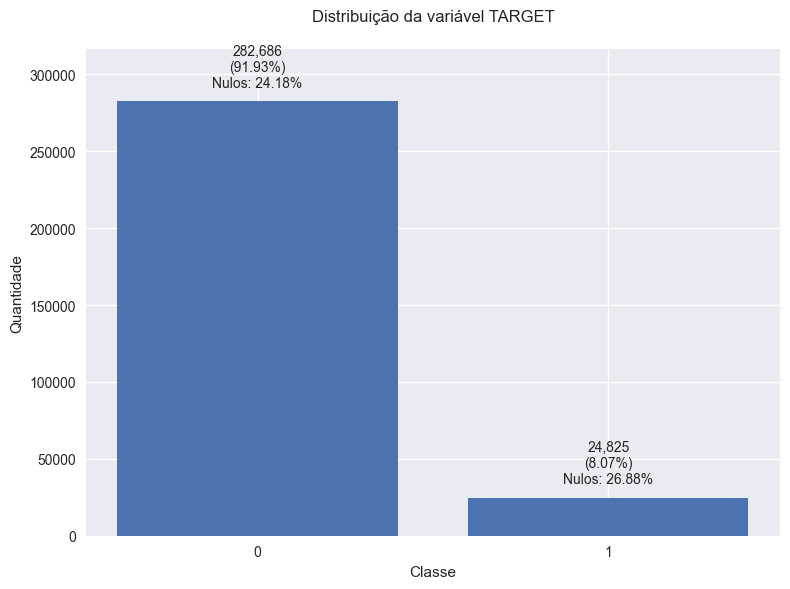

In [298]:
fig, ax = plt.subplots(figsize=(8, 6))

bars = ax.bar(
    resumo["TARGET"].astype(str),
    resumo["Quantidade"]
)

ax.set_xlabel("Classe")
ax.set_ylabel("Quantidade")
ax.set_title("Distribuição da variável TARGET", pad=20)

ax.set_ylim(0, resumo["Quantidade"].max() * 1.12)

for bar, qtd, pct, nul in zip(
    bars,
    resumo["Quantidade"],
    resumo["Percentual"],
    resumo["Taxa de Nulos (%)"]
):
    h = bar.get_height()

    ax.annotate(
        f"{qtd:,}\n({pct:.2f}%)\nNulos: {nul:.2f}%",
        xy=(bar.get_x() + bar.get_width()/2, h),
        xytext=(0, 8),               # desloca 8 pixels para cima
        textcoords="offset points",
        ha="center",
        va="bottom",
        fontsize=10
    )

plt.tight_layout()
plt.show()

In [299]:
bons = (dados["TARGET"] == 0).sum()
maus = (dados["TARGET"] == 1).sum()
total = len(dados)

taxa = maus / total
odds = bons / maus

clientes_por_mau = total / maus

print(f"Taxa de inadimplência: {taxa:.2%}")
print(f"Odds (Bom:Mau): {odds:.2f}:1")
print(f"A cada {clientes_por_mau:.0f} clientes, 1 é inadimplente.")

Taxa de inadimplência: 8.07%
Odds (Bom:Mau): 11.39:1
A cada 12 clientes, 1 é inadimplente.


**Análise**

Existe um forte desbalanceamento de classe no conjunto de dados, de 307.511 linhas, somente 8.07% pertence a classe 1, que são as pessoas que entraram em inadimplência. Além disso, a cada 12 clientes, 1 é inadimplente, reforçando a grande diferença entre os dois grupos. Nesse cenário, é provável que seja necessário a aplicação de técnicas de balanceamento de classes para harmonizar um pouco a relação.

### Análise Exploratória

In [300]:
coluns_nulls = {}
for coluna in dados.columns:
    nulls_count = dados[coluna].isnull().sum()
    nulls_pct = (nulls_count / len(dados)) * 100
    coluns_nulls[coluna] = {'count': nulls_count, 'percentage': nulls_pct}

coluns_nulls = pd.DataFrame.from_dict(coluns_nulls, orient='index')
coluns_nulls = coluns_nulls.sort_values('percentage', ascending=False)
coluns_nulls['percentage'] = coluns_nulls['percentage'].round(2)

In [301]:
coluns_nulls.head(5)

,count,percentage
COMMONAREA_MEDI,214865,69.87
COMMONAREA_AVG,214865,69.87
COMMONAREA_MODE,214865,69.87
NONLIVINGAPARTMENTS_MODE,213514,69.43
NONLIVINGAPARTMENTS_AVG,213514,69.43


In [302]:
# Variaveis que nao possuem nulo
vars_not_null = len(coluns_nulls[coluns_nulls['percentage'] == 0].index.tolist())
vars_not_null

58

In [303]:
# Variaveis que possuem mais de 50% de nulos
vars_50pct_null = len(coluns_nulls[coluns_nulls['percentage'] > 50].index.tolist())
vars_50pct_null

41

**Análise**

33% das variáveis possuem mais de 50% de valores nulos. Dentro dessa mesma linha, 58 colunas estão com todos os seus valores. Nesse sentido, fazer a imputação direta nessas 41 variáveis pode trazer maléficios no modelo. Para mitigar a problemática de remover essas colunas, será realizado uma análise estatística para escolher quais dessas variaveis apresentam um maior valor de discriminação entre as classes, aplicando técnicas como IV para verificar o ganho de informação e o ks para comparar as CDF dessas variáveis em relação ao target, aquelas que tiverem mais resultados, será criado uma coluna indicando que aquela coluna está nula.


### Avaliaçaõ das variáveis

Nesse cenário será aplicado algumas técnicas para verificar se algumas dessas 41 variáveis são realmente boas, seguindo a sequência:

* IV (manter variáveis com IV ≥ 0,02 como referência inicial).
* KS univariado (confirmar que há separação entre as distribuições) para as variáveis numéricas.
* WoE (avaliar monotonicidade e interpretar o comportamento de cada bin, incluindo o bin "Missing").
* Teste qui-quadrado
* V de Cramér - Força da variável com o target
* Correlação/VIF


In [304]:
# variaveis com mais de 50% de nulos
vars_50pct_null = coluns_nulls[coluns_nulls['percentage'] > 50].index.tolist()
df_vars_50pct_null = dados[vars_50pct_null]

### IV Information Value

Enquanto o WoE mede o comportamento de cada grupo, o information Value (IV) mede o poder preditivo da variável inteira, ela funciona da seguinte forma:

$$
IV =
\sum_{i=1}^{n}
(\%\,Bons_i-\%\,Maus_i)
\times
WoE_i
$$


- Primeiro calcula-se o WoE para cada grupo.
- depois mede-se a diferença entre a distribuição de bons e maus.
- finalmente soma-se a contribuição de bons e maus.

### Weight of Evidence (WoE)

É uma transformação estatística que mede o quanto uma determinada categoria ou variável contínua está associada ao evento de interesse que no caso é inadimplência.

Ele funciona da seguinte forma, para cada grupo de uma variável, compara-se a proporção de clientes boms com a proporção de clientes maus. O WoE transforma essa comparação em uma escala logarítmica.

* WoE positivo: %Bons > %Maus, então WoE > 0 - aquele grupo possui proporcionalmente mais clientes adimplentes do que inadimplentes, ou seja, menor risco de crédito.
* WoE negativo: %Bons < $Maus, então WoE < 0 - existe concentração relativamente maior de inadimplentes  - esse grupo representa maior risco.
* WoE %Bons = %Maus é 0, significa que aquela categoria possui exatamente a mesma distribuição da população geral, não indicando aumento nem redução do risco.


$$
WoE_i = \ln\left(\frac{\%\,Bons_i}{\%\,Maus_i}\right)
$$

In [305]:
# DataFrame de resultados
df_resultados = pd.DataFrame({"Variavel": df_vars_50pct_null.columns})

# Tipo da variável
df_resultados["Tipo"] = [
    "Numerica" if pd.api.types.is_numeric_dtype(df_vars_50pct_null[col]) else "Categorica"
    for col in df_vars_50pct_null.columns
]

# Percentual de nulos
df_resultados["% Nulos"] = [
    df_vars_50pct_null[col].isna().mean() * 100
    for col in df_vars_50pct_null.columns
]

ivs = []

for col in df_vars_50pct_null.columns:

    df_aux = pd.DataFrame({
        "x": df_vars_50pct_null[col],
        "target": dados["TARGET"]
    })

    # Cria os bins
    if pd.api.types.is_numeric_dtype(df_aux["x"]):

        try:
            df_aux["bin"] = pd.qcut(df_aux["x"], q=10, duplicates="drop")
        except:
            df_aux["bin"] = df_aux["x"]

    else:
        df_aux["bin"] = df_aux["x"]

    # Trata valores ausentes como uma categoria
    df_aux["bin"] = df_aux["bin"].astype("object")
    df_aux["bin"] = df_aux["bin"].fillna("Missing")

    # Agrupa bons e maus
    tabela = df_aux.groupby("bin")["target"].agg(
        Bons=lambda x: (x == 0).sum(),
        Maus=lambda x: (x == 1).sum()
    )

    # Evita divisão por zero
    tabela["Bons"] = tabela["Bons"].replace(0, 0.5)
    tabela["Maus"] = tabela["Maus"].replace(0, 0.5)

    # Percentuais
    tabela["Pct_Bons"] = tabela["Bons"] / tabela["Bons"].sum()
    tabela["Pct_Maus"] = tabela["Maus"] / tabela["Maus"].sum()

    # WoE
    tabela["WoE"] = np.log(tabela["Pct_Bons"] / tabela["Pct_Maus"])

    # IV
    tabela["IV"] = (tabela["Pct_Bons"] - tabela["Pct_Maus"]) * tabela["WoE"]

    ivs.append(tabela["IV"].sum())

df_resultados["IV"] = ivs

In [306]:
df_resultados.head()

,Variavel,Tipo,% Nulos,IV
0,COMMONAREA_MEDI,Numerica,69.872297,0.014262
1,COMMONAREA_AVG,Numerica,69.872297,0.014330
2,COMMONAREA_MODE,Numerica,69.872297,0.012980
3,NONLIVINGAPARTMENTS_MODE,Numerica,69.432963,0.011715
4,NONLIVINGAPARTMENTS_AVG,Numerica,69.432963,0.011814


### KS Univariado

É uma adaptação do teste de Kolmogorov-Smirnov para avaliar uma única variável por vez. Esse é um teste estatístico não paramétrico ou seja, não existe a hipótese de que uma determinada variável possui algum comportamento de uma distribuição teórica. Ele vai responder a seguinte pergunta:

**A distribuição dessa variável é diferente entre os clientes adimplentes e inadimplentes?**

Ele vai comparar as duas CDF (Função densidade de probabilidade) e medir o quanto essas duas distribuições são diferentes. Quanto maior essa diferença, maior o potencial daquela variável para separar as classes.

$$
KS = \max_{x} \left| F_0(x) - F_1(x) \right|
$$

Onde:

- (KS): estatística de Kolmogorov-Smirnov;
- (F_0(x)): função de distribuição acumulada (CDF) da variável para os clientes **adimplentes** (\(TARGET = 0\));
- (F_1(x)): função de distribuição acumulada (CDF) da variável para os clientes **inadimplentes** (\(TARGET = 1\));
- (max_x): maior diferença observada ao longo de todos os valores possíveis da variável;
- (|F_0(x)-F_1(x)|): distância absoluta entre as duas distribuições acumuladas.


In [307]:
from scipy.stats import ks_2samp
import numpy as np

ks_values = []

for col in df_vars_50pct_null.columns:

    # KS é aplicado apenas em variáveis numéricas
    if not pd.api.types.is_numeric_dtype(df_vars_50pct_null[col]):
        ks_values.append(np.nan)
        continue

    df_aux = pd.DataFrame({
        "x": df_vars_50pct_null[col],
        "target": dados["TARGET"]
    }).dropna()

    grupo_bons = df_aux.loc[df_aux["target"] == 0, "x"]
    grupo_maus = df_aux.loc[df_aux["target"] == 1, "x"]

    ks = ks_2samp(grupo_bons, grupo_maus).statistic

    ks_values.append(ks)

df_resultados["KS"] = ks_values

In [308]:
df_resultados.head()

,Variavel,Tipo,% Nulos,IV,KS
0,COMMONAREA_MEDI,Numerica,69.872297,0.014262,0.034060
1,COMMONAREA_AVG,Numerica,69.872297,0.014330,0.033877
2,COMMONAREA_MODE,Numerica,69.872297,0.012980,0.031678
3,NONLIVINGAPARTMENTS_MODE,Numerica,69.432963,0.011715,0.012449
4,NONLIVINGAPARTMENTS_AVG,Numerica,69.432963,0.011814,0.015454


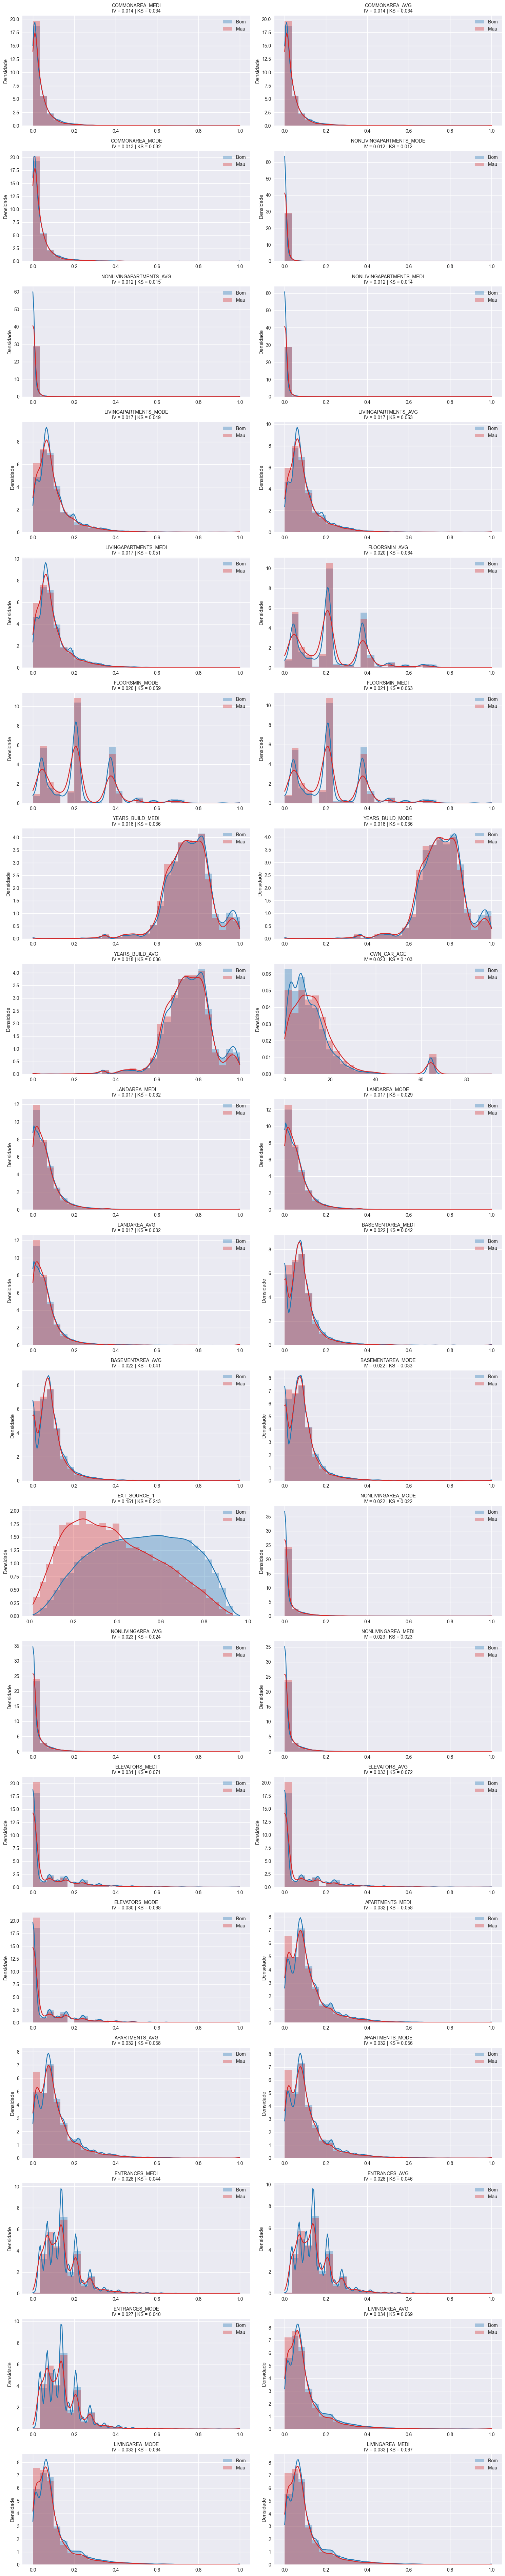

In [309]:
import math
import matplotlib.pyplot as plt
import seaborn as sns

num_cols = df_resultados.loc[df_resultados["Tipo"] == "Numerica", "Variavel"].tolist()

n_cols = 2
n_rows = math.ceil(len(num_cols) / n_cols)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, 4 * n_rows))
axes = axes.flatten()

for ax, col in zip(axes, num_cols):

    # Bons
    sns.histplot(
        data=dados.loc[dados["TARGET"] == 0],
        x=col,
        stat="density",
        kde=True,
        bins=30,
        color="#1f77b4",
        alpha=0.35,
        edgecolor=None,
        ax=ax,
        label="Bom"
    )

    # Maus
    sns.histplot(
        data=dados.loc[dados["TARGET"] == 1],
        x=col,
        stat="density",
        kde=True,
        bins=30,
        color="#d62728",
        alpha=0.35,
        edgecolor=None,
        ax=ax,
        label="Mau"
    )

    # Recupera IV e KS da variável
    iv = df_resultados.loc[df_resultados["Variavel"] == col, "IV"].iloc[0]
    ks = df_resultados.loc[df_resultados["Variavel"] == col, "KS"].iloc[0]

    ax.set_title(f"{col}\nIV = {iv:.3f} | KS = {ks:.3f}", fontsize=10)
    ax.set_xlabel("")
    ax.set_ylabel("Densidade")
    ax.legend()

# Remove eixos vazios
for ax in axes[len(num_cols):]:
    fig.delaxes(ax)

plt.tight_layout()
plt.show()

### Teste Qui-quadrado

O teste do Qui-quadrado de independência é um método estatístico utilizado para verificar se existe associação entre duas variáveis categóricas.

A hipótese nula do teste estabelece que as duas variáveis são independentes, isto é, que conhecer o valor da variável explicativa não altera a distribuição do target.

**Hipótese Nula (h0):** A variável explicativa e o target são independentes.
**Hipótese alternativa (h1):** Existe associação entre a variável explicativa e o target.

O teste compara as frequências observadas com as frequências esperadas caso não existisse qualquer associação entre as variáveis.

$$
E_{ij} =
\frac{(\text{Total da linha}_i)\times(\text{Total da coluna}_j)}
{\text{Total Geral}}
$$

Uma vez obtidas as frequências esperadas, calcula-se a estatística do Qui-quadrado:

$$
\chi^2 =
\sum_{i=1}^{r}
\sum_{j=1}^{c}
\frac{(O_{ij}-E_{ij})^2}
{E_{ij}}
$$

* Oij: frequencia observada
* Eij: frequencia esperada
* r: numero de linhas da tabela
* c: numero de columas da tabela

### V de Cramér

É uma medida estatística que quantifica a intensidade da associação entre duas variáveis categóricas. A diferença entre ele e o teste Qui-Quadrado é que o V de Cramér realiza uma normalização da estatística, permitindo comparar variáveis mesmo quando a base possui um grande número de observações.

$$
V =
\sqrt{
\frac{\chi^2}
{n \times \min(r-1,\;c-1)}
}
$$

Onde:

* X^2: estatística do teste do qui-quadrado
* n: número total de observações
* r: numero de linhas da tabela de contingência
* c: número de colunas da tabela de contingência
* min(r-1, c-1): menor número de graus de liberdade entre as dimensões da tabela.

A normalização torna o resultado independente da escada da amostra, fazendo com que o V de Cramér assuma sempre valores entre 0 e 1.

In [310]:
from scipy.stats import chi2_contingency

qui2 = []
v_cramer = []

for col in df_vars_50pct_null.columns:

    # Apenas variáveis categóricas
    if pd.api.types.is_numeric_dtype(df_vars_50pct_null[col]):
        qui2.append(np.nan)
        v_cramer.append(np.nan)
        continue

    df_aux = pd.DataFrame({
        "x": df_vars_50pct_null[col].fillna("Missing"),
        "target": dados["TARGET"]
    })

    tabela = pd.crosstab(df_aux["x"], df_aux["target"])

    chi2, p, dof, expected = chi2_contingency(tabela)

    n = tabela.to_numpy().sum()
    r, c = tabela.shape

    v = np.sqrt(chi2 / (n * min(r - 1, c - 1)))

    qui2.append(chi2)
    v_cramer.append(v)

df_resultados["Qui_Quadrado"] = qui2
df_resultados["V_Cramer"] = v_cramer

In [311]:
df_resultados

,Variavel,Tipo,% Nulos,IV,KS,Qui_Quadrado,V_Cramer
0,COMMONAREA_MEDI,Numerica,69.872297,0.014262,0.034060,NaN,NaN
1,COMMONAREA_AVG,Numerica,69.872297,0.014330,0.033877,NaN,NaN
2,COMMONAREA_MODE,Numerica,69.872297,0.012980,0.031678,NaN,NaN
3,NONLIVINGAPARTMENTS_MODE,Numerica,69.432963,0.011715,0.012449,NaN,NaN
4,NONLIVINGAPARTMENTS_AVG,Numerica,69.432963,0.011814,0.015454,NaN,NaN
5,NONLIVINGAPARTMENTS_MEDI,Numerica,69.432963,0.011812,0.013856,NaN,NaN
6,FONDKAPREMONT_MODE,Categorica,68.386172,0.013021,NaN,281.716375,0.030267
7,LIVINGAPARTMENTS_MODE,Numerica,68.354953,0.016881,0.048827,NaN,NaN
8,LIVINGAPARTMENTS_AVG,Numerica,68.354953,0.017253,0.053160,NaN,NaN
9,LIVINGAPARTMENTS_MEDI,Numerica,68.354953,0.017240,0.051374,NaN,NaN


### Analisando as variaveis de missing

In [312]:
# Cria as flags de missing (1 = Missing, 0 = Não Missing)
df_missing = df_vars_50pct_null.isna().astype(int)

df_missing.columns = [f"{col}_missing" for col in df_missing.columns]
df_missing["TARGET"] = dados["TARGET"].values
df_missing.head()

,COMMONAREA_MEDI_missing,COMMONAREA_AVG_missing,COMMONAREA_MODE_missing,NONLIVINGAPARTMENTS_MODE_missing,NONLIVINGAPARTMENTS_AVG_missing,NONLIVINGAPARTMENTS_MEDI_missing,FONDKAPREMONT_MODE_missing,LIVINGAPARTMENTS_MODE_missing,LIVINGAPARTMENTS_AVG_missing,LIVINGAPARTMENTS_MEDI_missing,...,APARTMENTS_AVG_missing,APARTMENTS_MODE_missing,ENTRANCES_MEDI_missing,ENTRANCES_AVG_missing,ENTRANCES_MODE_missing,LIVINGAREA_AVG_missing,LIVINGAREA_MODE_missing,LIVINGAREA_MEDI_missing,HOUSETYPE_MODE_missing,TARGET
0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,1
1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,1,1,1,1,1,1,1,1,1,1,...,1,1,1,1,1,1,1,1,1,0
3,1,1,1,1,1,1,1,1,1,1,...,1,1,1,1,1,1,1,1,1,0
4,1,1,1,1,1,1,1,1,1,1,...,1,1,1,1,1,1,1,1,1,0


In [313]:
def avaliar_variaveis(df, target):

    resultados = []

    for col in df.columns:

        if col == target:
            continue

        df_aux = pd.DataFrame({
            "x": df[col].fillna("Missing"),
            "target": df[target]
        })

        # Tabela de contingência
        tabela = pd.crosstab(df_aux["x"], df_aux["target"])

        # Bons e Maus
        bons = tabela.get(0, pd.Series(dtype=float)).replace(0, 0.5)
        maus = tabela.get(1, pd.Series(dtype=float)).replace(0, 0.5)

        pct_bons = bons / bons.sum()
        pct_maus = maus / maus.sum()

        # WoE
        woe = np.log(pct_bons / pct_maus)

        # IV
        iv = ((pct_bons - pct_maus) * woe).sum()

        # Qui-quadrado
        chi2, p, _, _ = chi2_contingency(tabela)

        # V de Cramér
        n = tabela.values.sum()
        r, c = tabela.shape

        if min(r - 1, c - 1) == 0:
            v = np.nan
        else:
            v = np.sqrt(chi2 / (n * min(r - 1, c - 1)))

        # WoE do Missing
        woe_missing = np.nan
        if 1 in tabela.index:
            woe_missing = woe.loc[1]

        resultados.append({
            "Variavel": col,
            "% Missing": df[col].mean() * 100,
            "IV": iv,
            "WoE Missing": woe_missing,
            "Qui_Quadrado": chi2,
            "p_valor": p,
            "V_Cramer": v
        })

    return pd.DataFrame(resultados)

In [314]:
df_missing_resultados = avaliar_variaveis(df_missing, "TARGET")

In [315]:
df_missing_resultados

,Variavel,% Missing,IV,WoE Missing,Qui_Quadrado,p_valor,V_Cramer
0,COMMONAREA_MEDI_missing,69.872297,0.011036,-0.065718,241.316637,2.030594e-54,0.028013
1,COMMONAREA_AVG_missing,69.872297,0.011036,-0.065718,241.316637,2.030594e-54,0.028013
2,COMMONAREA_MODE_missing,69.872297,0.011036,-0.065718,241.316637,2.030594e-54,0.028013
3,NONLIVINGAPARTMENTS_MODE_missing,69.432963,0.011206,-0.066903,245.197049,2.894452e-55,0.028238
4,NONLIVINGAPARTMENTS_AVG_missing,69.432963,0.011206,-0.066903,245.197049,2.894452e-55,0.028238
5,NONLIVINGAPARTMENTS_MEDI_missing,69.432963,0.011206,-0.066903,245.197049,2.894452e-55,0.028238
6,FONDKAPREMONT_MODE_missing,68.386172,0.012192,-0.071397,266.948634,5.247529e-60,0.029463
7,LIVINGAPARTMENTS_MODE_missing,68.354953,0.012288,-0.071716,269.020242,1.855430e-60,0.029578
8,LIVINGAPARTMENTS_AVG_missing,68.354953,0.012288,-0.071716,269.020242,1.855430e-60,0.029578
9,LIVINGAPARTMENTS_MEDI_missing,68.354953,0.012288,-0.071716,269.020242,1.855430e-60,0.029578


|          IV | Interpretação                                             |
| ----------: | --------------------------------------------------------- |
|      < 0,02 | Sem poder preditivo                                       |
| 0,02 – 0,10 | Fraco                                                     |
| 0,10 – 0,30 | Médio                                                     |
| 0,30 – 0,50 | Forte                                                     |
|      > 0,50 | Muito forte (investigar possível vazamento de informação) |


WoE negativo nos diz que, aquele comportamento da variável está relacionado a pessoas com o perfil de inadimplente.

In [316]:
df_eda = dados.copy()

# Variáveis a remover
cols_remover = [
    "COMMONAREA_MEDI", "COMMONAREA_MODE",
    "NONLIVINGAPARTMENTS_MEDI", "NONLIVINGAPARTMENTS_MODE",
    "LIVINGAPARTMENTS_MEDI", "LIVINGAPARTMENTS_MODE",
    "FLOORSMIN_AVG", "FLOORSMIN_MODE",
    "YEARS_BUILD_AVG", "YEARS_BUILD_MEDI",
    "LANDAREA_AVG", "LANDAREA_MODE",
    "BASEMENTAREA_MEDI", "BASEMENTAREA_MODE",
    "NONLIVINGAREA_MEDI", "NONLIVINGAREA_MODE",
    "ELEVATORS_MEDI", "ELEVATORS_MODE",
    "APARTMENTS_MEDI", "APARTMENTS_MODE",
    "ENTRANCES_MEDI", "ENTRANCES_MODE",
    "LIVINGAREA_MEDI", "LIVINGAREA_MODE"
]

df_eda.drop(columns=cols_remover, inplace=True)

# Cria as flags de missing
grupos_missing = {
    "COMMONAREA_missing": "COMMONAREA_AVG",
    "NONLIVINGAPARTMENTS_missing": "NONLIVINGAPARTMENTS_AVG",
    "LIVINGAPARTMENTS_missing": "LIVINGAPARTMENTS_AVG",
    "FLOORSMIN_missing": "FLOORSMIN_MEDI",
    "YEARS_BUILD_missing": "YEARS_BUILD_MODE",
    "LANDAREA_missing": "LANDAREA_MEDI",
    "BASEMENTAREA_missing": "BASEMENTAREA_AVG",
    "NONLIVINGAREA_missing": "NONLIVINGAREA_AVG",
    "ELEVATORS_missing": "ELEVATORS_AVG",
    "APARTMENTS_missing": "APARTMENTS_AVG",
    "ENTRANCES_missing": "ENTRANCES_AVG",
    "LIVINGAREA_missing": "LIVINGAREA_AVG"
}

for nova_col, col_ref in grupos_missing.items():
    df_eda[nova_col] = df_eda[col_ref].isna().astype(int)

In [317]:
df_eda.describe()

,SK_ID_CURR,TARGET,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,AMT_GOODS_PRICE,REGION_POPULATION_RELATIVE,DAYS_BIRTH,DAYS_EMPLOYED,...,LIVINGAPARTMENTS_missing,FLOORSMIN_missing,YEARS_BUILD_missing,LANDAREA_missing,BASEMENTAREA_missing,NONLIVINGAREA_missing,ELEVATORS_missing,APARTMENTS_missing,ENTRANCES_missing,LIVINGAREA_missing
count,307511.000000,307511.000000,307511.000000,3.075110e+05,3.075110e+05,307499.000000,3.072330e+05,307511.000000,307511.000000,307511.000000,...,307511.000000,307511.000000,307511.000000,307511.000000,307511.000000,307511.000000,307511.000000,307511.000000,307511.000000,307511.000000
mean,278180.518577,0.080729,0.417052,1.687979e+05,5.990260e+05,27108.573909,5.383962e+05,0.020868,-16036.995067,63815.045904,...,0.683550,0.678486,0.664978,0.593767,0.585160,0.551792,0.532960,0.507497,0.503488,0.501933
std,102790.175348,0.272419,0.722121,2.371231e+05,4.024908e+05,14493.737315,3.694465e+05,0.013831,4363.988632,141275.766519,...,0.465092,0.467058,0.471999,0.491130,0.492695,0.497311,0.498913,0.499945,0.499989,0.499997
min,100002.000000,0.000000,0.000000,2.565000e+04,4.500000e+04,1615.500000,4.050000e+04,0.000290,-25229.000000,-17912.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,189145.500000,0.000000,0.000000,1.125000e+05,2.700000e+05,16524.000000,2.385000e+05,0.010006,-19682.000000,-2760.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,278202.000000,0.000000,0.000000,1.471500e+05,5.135310e+05,24903.000000,4.500000e+05,0.018850,-15750.000000,-1213.000000,...,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000
75%,367142.500000,0.000000,1.000000,2.025000e+05,8.086500e+05,34596.000000,6.795000e+05,0.028663,-12413.000000,-289.000000,...,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000
max,456255.000000,1.000000,19.000000,1.170000e+08,4.050000e+06,258025.500000,4.050000e+06,0.072508,-7489.000000,365243.000000,...,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


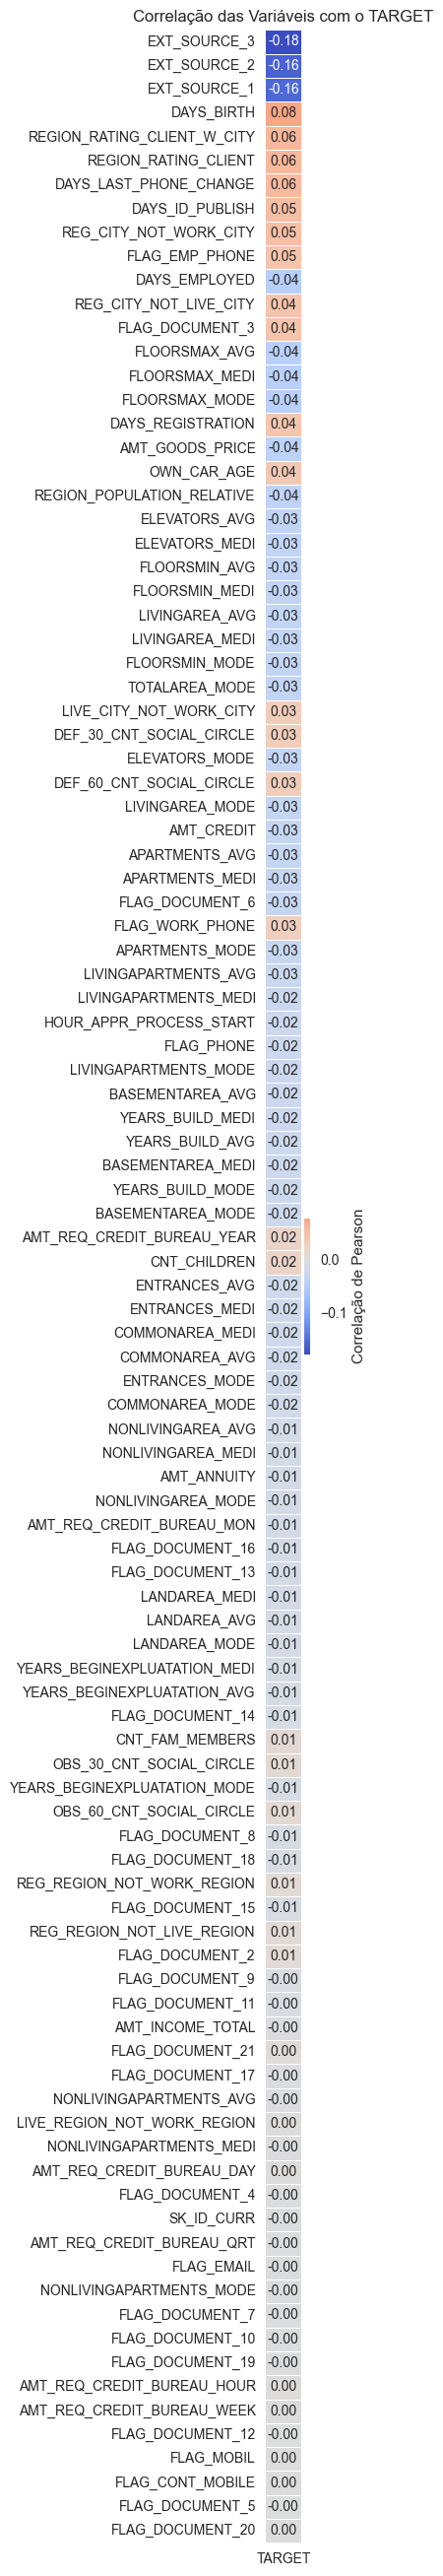

In [318]:
from sklearn.preprocessing import LabelEncoder

dados_corr = dados.copy()

# Label Encoder no TARGET
le = LabelEncoder()
dados_corr["TARGET"] = le.fit_transform(dados_corr["TARGET"])

# Matriz de correlação
matriz_correlacao = dados_corr.corr(method="pearson", numeric_only=True)

# Correlação com o TARGET
correlacao_target = (
    matriz_correlacao["TARGET"]
    .drop("TARGET")
    .sort_values(key=abs, ascending=False)
)

# Heatmap da correlação com o TARGET
plt.figure(figsize=(4, max(8, len(correlacao_target) * 0.25)))

sns.heatmap(
    correlacao_target.to_frame(),
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0,
    linewidths=0.5,
    cbar_kws={"label": "Correlação de Pearson"}
)

plt.title("Correlação das Variáveis com o TARGET")
plt.tight_layout()
plt.show()

In [319]:
df_eda['EXT_SOURCE_COMPLT_MEAN'] = df_eda[['EXT_SOURCE_1', 'EXT_SOURCE_2', 'EXT_SOURCE_3']].mean(axis=1)
df_eda['EXT_SOURCE_COMPLT_SUM'] = df_eda[['EXT_SOURCE_1', 'EXT_SOURCE_2', 'EXT_SOURCE_3']].sum(axis=1)
df_eda['EXT_SOURCE_COMPLT_STD'] = df_eda[['EXT_SOURCE_1', 'EXT_SOURCE_2', 'EXT_SOURCE_3']].std(axis=1)

In [320]:
df_eda['EXT_SOURCE_1']

0         0.083037
1         0.311267
2              NaN
3              NaN
4              NaN
            ...   
307506    0.145570
307507         NaN
307508    0.744026
307509         NaN
307510    0.734460
Name: EXT_SOURCE_1, Length: 307511, dtype: float64

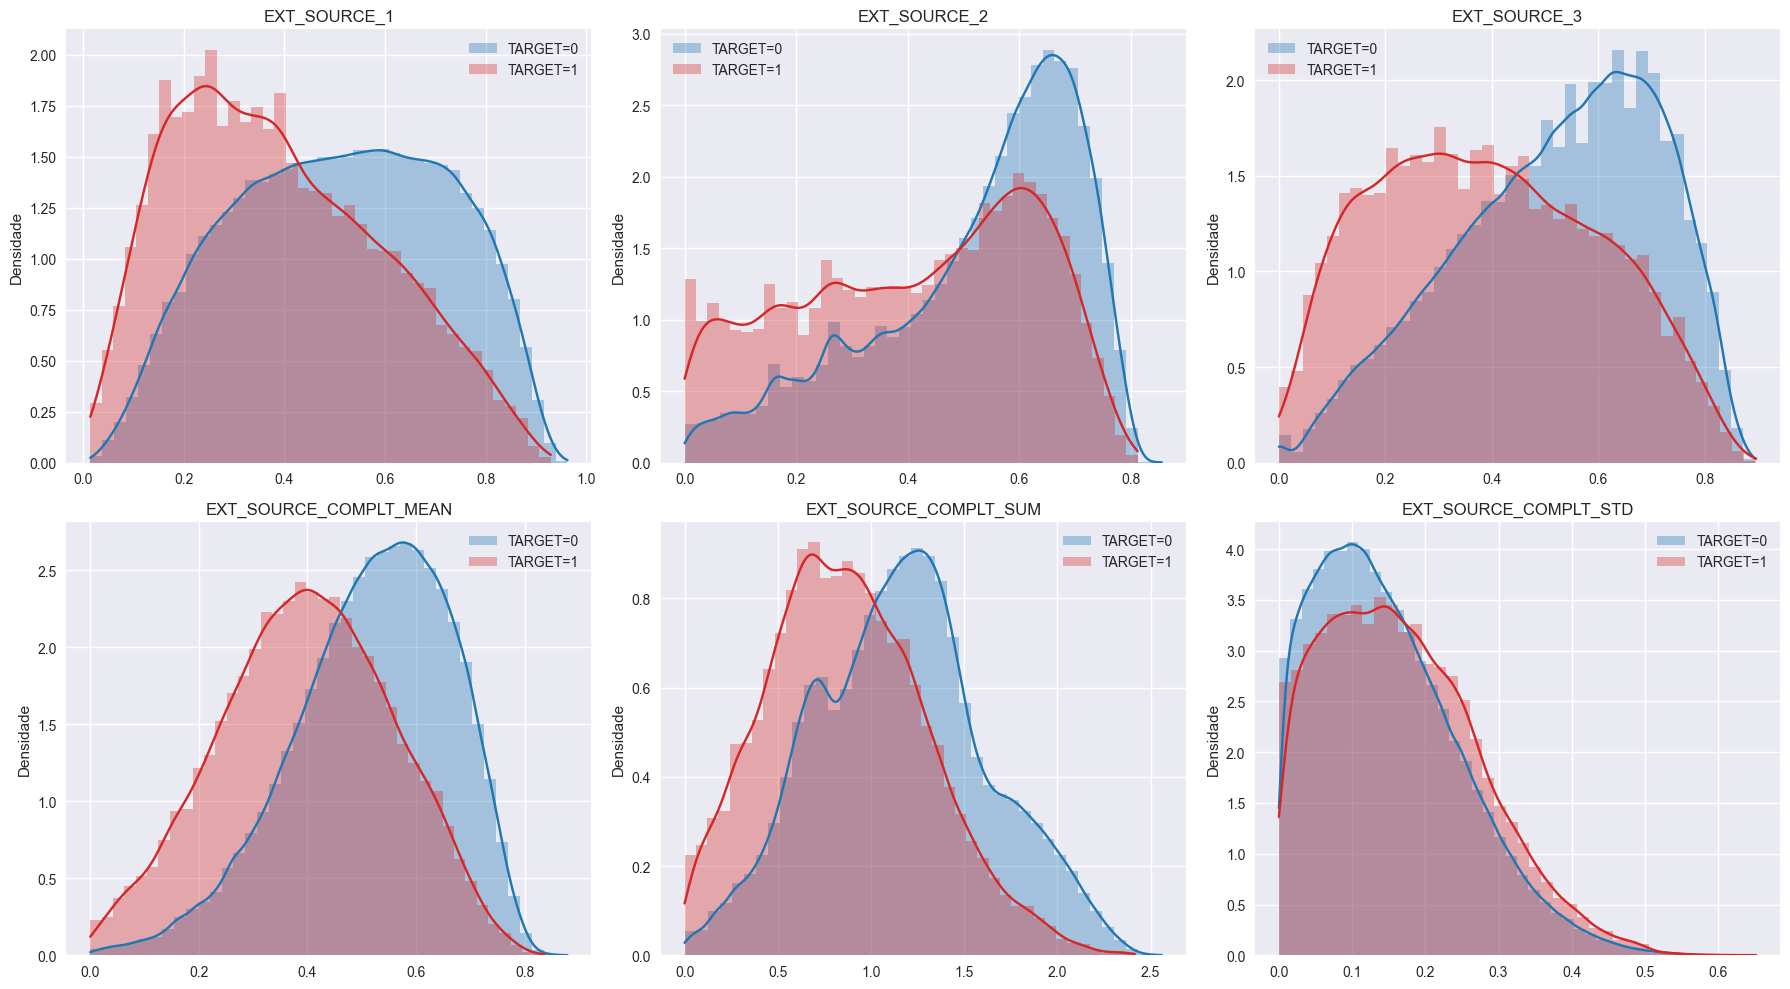

In [321]:
variaveis = [
    "EXT_SOURCE_1",
    "EXT_SOURCE_2",
    "EXT_SOURCE_3",
    "EXT_SOURCE_COMPLT_MEAN",
    "EXT_SOURCE_COMPLT_SUM",
    "EXT_SOURCE_COMPLT_STD"
]

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

cores = {0: "#1f77b4", 1: "#d62728"}

for ax, var in zip(axes, variaveis):

    for classe in sorted(df_eda["TARGET"].unique()):

        serie = df_eda.loc[df_eda["TARGET"] == classe, var].dropna()

        sns.histplot(
            serie,
            stat="density",
            bins=40,
            kde=True,
            color=cores[classe],
            alpha=0.35,
            edgecolor=None,
            ax=ax,
            label=f"TARGET={classe}"
        )

    ax.set_title(var)
    ax.set_xlabel("")
    ax.set_ylabel("Densidade")
    ax.legend()

plt.tight_layout()
plt.show()

**Análise**

Após o processo de combinar as variáveis EXIT_SOURCE, idenficando graficamente, a variável agrupada EXT_SOUCE_COMPLT_MEAN apresenta uma boa separação entre as classes, será aplicado os testes estatísticos nessas novas variáveis para avaliarmos seu poder discriminatório.

In [322]:
def avaliar_variaveis_continuas(df, variaveis, target, n_bins=10):

    resultados = []

    for col in variaveis:

        df_aux = df[[col, target]].copy()

        # % Missing
        pct_missing = df_aux[col].isna().mean() * 100

        # ------------------------
        # KS
        # ------------------------
        grupo_0 = df_aux.loc[df_aux[target] == 0, col].dropna()
        grupo_1 = df_aux.loc[df_aux[target] == 1, col].dropna()

        ks, ks_p = ks_2samp(grupo_0, grupo_1)

        # ------------------------
        # Discretização
        # ------------------------
        df_aux["bin"] = np.nan

        mask = df_aux[col].notna()

        df_aux.loc[mask, "bin"] = pd.qcut(
            df_aux.loc[mask, col],
            q=n_bins,
            duplicates="drop"
        ).astype(str)

        df_aux["bin"] = df_aux["bin"].fillna("Missing")

        # ------------------------
        # Tabela WoE
        # ------------------------
        tabela = pd.crosstab(df_aux["bin"], df_aux[target])

        bons = tabela.get(0, pd.Series(dtype=float)).replace(0, 0.5)
        maus = tabela.get(1, pd.Series(dtype=float)).replace(0, 0.5)

        pct_bons = bons / bons.sum()
        pct_maus = maus / maus.sum()

        woe = np.log(pct_bons / pct_maus)

        iv = ((pct_bons - pct_maus) * woe).sum()

        # ------------------------
        # Qui-quadrado
        # ------------------------
        chi2, p, _, _ = chi2_contingency(tabela)

        # ------------------------
        # V de Cramér
        # ------------------------
        n = tabela.values.sum()

        if min(tabela.shape) <= 1:
            v = np.nan
        else:
            v = np.sqrt(
                chi2 / (n * min(tabela.shape[0]-1, tabela.shape[1]-1))
            )

        resultados.append({
            "Variavel": col,
            "% Missing": round(pct_missing, 2),
            "KS": round(ks, 4),
            "KS_pvalor": ks_p,
            "IV": round(iv, 4),
            "WoE Missing": woe.get("Missing", np.nan),
            "Qui_Quadrado": round(chi2, 2),
            "p_valor": p,
            "V_Cramer": round(v, 4),
            "Bins": len(tabela)
        })

    return (
        pd.DataFrame(resultados)
        .sort_values("KS", ascending=False)
        .reset_index(drop=True)
    )

In [323]:
variaveis = [
    "EXT_SOURCE_COMPLT_MEAN",
    "EXT_SOURCE_COMPLT_SUM",
    "EXT_SOURCE_COMPLT_STD"
]

df_vars_test = df_eda[variaveis + ["TARGET"]].copy()

In [324]:
resultado = avaliar_variaveis_continuas(
    df=df_eda,
    variaveis=variaveis,
    target="TARGET",
    n_bins=10
)

resultado

,Variavel,% Missing,KS,KS_pvalor,IV,WoE Missing,Qui_Quadrado,p_valor,V_Cramer,Bins
0,EXT_SOURCE_COMPLT_MEAN,0.06,0.3241,0.000000e+00,0.6083,-0.008948,15540.66,0.000000e+00,0.2248,11
1,EXT_SOURCE_COMPLT_SUM,0.00,0.2735,0.000000e+00,0.4300,NaN,9960.16,0.000000e+00,0.1800,10
2,EXT_SOURCE_COMPLT_STD,12.00,0.0805,2.698101e-110,0.0359,-0.225621,839.01,8.438493e-174,0.0522,11


In [325]:
df_eda[
    [
        "EXT_SOURCE_COMPLT_MEAN",
        "EXT_SOURCE_COMPLT_SUM",
        "EXT_SOURCE_COMPLT_STD"
    ]
].corr(method="spearman")

,EXT_SOURCE_COMPLT_MEAN,EXT_SOURCE_COMPLT_SUM,EXT_SOURCE_COMPLT_STD
EXT_SOURCE_COMPLT_MEAN,1.000000,0.642137,-0.347272
EXT_SOURCE_COMPLT_SUM,0.642137,1.000000,-0.169093
EXT_SOURCE_COMPLT_STD,-0.347272,-0.169093,1.000000


**Análise**

As variáveis agrupadas EXT_SOURCE_COMPLT_MEAN e EXT_SOURCE_COMPLT_SUM, apresentaram ter bom poder discriminativo com base no teste estatístico KS e a análise utilizando o Information Value. Nesse sentido, sera descartado a variavel EXT_SOURCE_COMPLT_SD por não ter demonstrado o mesmo poder que as outras variáveis agrupadas.


In [326]:
# Removendo EXT_SOURCE_COMPLT_STD
df_eda = df_eda.drop(columns=["EXT_SOURCE_COMPLT_STD"], axis = 1)

In [327]:
df_eda

,SK_ID_CURR,TARGET,NAME_CONTRACT_TYPE,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,...,YEARS_BUILD_missing,LANDAREA_missing,BASEMENTAREA_missing,NONLIVINGAREA_missing,ELEVATORS_missing,APARTMENTS_missing,ENTRANCES_missing,LIVINGAREA_missing,EXT_SOURCE_COMPLT_MEAN,EXT_SOURCE_COMPLT_SUM
0,100002,1,Cash loans,M,N,Y,0,202500.0,406597.5,24700.5,...,0,0,0,0,0,0,0,0,0.161787,0.485361
1,100003,0,Cash loans,F,N,N,0,270000.0,1293502.5,35698.5,...,0,0,0,0,0,0,0,0,0.466757,0.933513
2,100004,0,Revolving loans,M,Y,Y,0,67500.0,135000.0,6750.0,...,1,1,1,1,1,1,1,1,0.642739,1.285479
3,100006,0,Cash loans,F,N,Y,0,135000.0,312682.5,29686.5,...,1,1,1,1,1,1,1,1,0.650442,0.650442
4,100007,0,Cash loans,M,N,Y,0,121500.0,513000.0,21865.5,...,1,1,1,1,1,1,1,1,0.322738,0.322738
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
307506,456251,0,Cash loans,M,N,N,0,157500.0,254700.0,27558.0,...,0,0,0,0,0,0,0,0,0.413601,0.827203
307507,456252,0,Cash loans,F,N,Y,0,72000.0,269550.0,12001.5,...,0,0,0,0,0,0,0,0,0.115992,0.115992
307508,456253,0,Cash loans,F,N,Y,0,153000.0,677664.0,29979.0,...,0,1,0,0,0,0,0,0,0.499536,1.498607
307509,456254,1,Cash loans,F,N,Y,0,171000.0,370107.0,20205.0,...,1,1,1,1,1,0,0,0,0.587593,1.175186


### Qual tipo de contrato está concentrado em clientes inadimplentes e com base nisso, existe alguma associação do tipo de contrato com a variável target?

In [328]:
tabela = pd.crosstab(
    df_eda["NAME_CONTRACT_TYPE"],
    df_eda["TARGET"]
)

tabela.columns = ["Bom", "Mau"]

tabela["Total"] = tabela["Bom"] + tabela["Mau"]
tabela["Taxa Default"] = tabela["Mau"] / tabela["Total"] * 100
tabela["Odds"] = tabela["Mau"] / tabela["Bom"]
tabela

,Bom,Mau,Total,Taxa Default,Odds
NAME_CONTRACT_TYPE,,,,,
Cash loans,255011,23221,278232,8.345913,0.091059
Revolving loans,27675,1604,29279,5.478329,0.057958


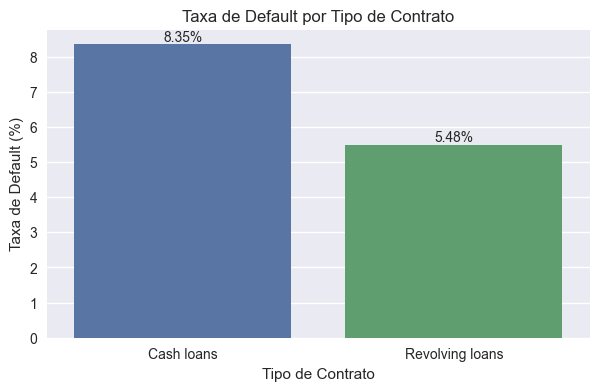

In [329]:
dados = tabela.reset_index()

plt.figure(figsize=(7, 4))

ax = sns.barplot(
    data=dados,
    x="NAME_CONTRACT_TYPE",
    y="Taxa Default"
)

for i, v in enumerate(dados["Taxa Default"]):
    ax.text(i, v + 0.1, f"{v:.2f}%", ha="center")

plt.title("Taxa de Default por Tipo de Contrato")
plt.xlabel("Tipo de Contrato")
plt.ylabel("Taxa de Default (%)")

plt.show()

In [330]:
tabela = pd.crosstab(df_eda['NAME_CONTRACT_TYPE'], df_eda['TARGET'])

# Qui-quadrado
chi2, p, _, _ = chi2_contingency(tabela)

print(f"Qui-quadrado: {chi2:.2f}")
print(f"p-value: {p:.6f}")

if p < 0.05:
    print("Rejeitamos a hipótese nula: Existe associação entre NAME_CONTRACT_TYPE e TARGET.")
else:
    print("Não rejeitamos a hipótese nula: Não há evidências suficientes de associação entre NAME_CONTRACT_TYPE e TARGET.")

# -------------------------
# V de Cramér
# -------------------------
n = tabela.to_numpy().sum()
r, c = tabela.shape

v_cramer = np.sqrt(chi2 / (n * min(r - 1, c - 1)))

print(f"V de Cramér: {v_cramer:.4f}")

# Interpretação
if v_cramer < 0.10:
    intensidade = "muito fraca"
elif v_cramer < 0.30:
    intensidade = "fraca"
elif v_cramer < 0.50:
    intensidade = "moderada"
else:
    intensidade = "forte"

print(f"Força da associação: {intensidade}")

Qui-quadrado: 293.15
p-value: 0.000000
Rejeitamos a hipótese nula: Existe associação entre NAME_CONTRACT_TYPE e TARGET.
V de Cramér: 0.0309
Força da associação: muito fraca


**Análise**

Como o conjunto de dados possui muitos registros, o teste qui-quadrado poder dar uma falsa rejeição na hipótese nula. Nesse caso, foi aplicado o teste V de Cramér para mensurar a força associação e o resultado obtido é que essa relação é fraca. Além disso, Cash Loans possui mais casos de inadimplência representando 8.34%. utilizando a formula ODDs ratio = Odds(loas) / Odds(Revolving Locas) chegamos na informação de que a odds de inadimplência dos clientes com Cash loans são aproximadamente 1,57 vezes as dos clientes com Revolving loans um aumento de aproximadamente 57% nas odds de inadimplência em relação ao tipo Revolving loans.

### Existe algum gênero com maior propensão a inadimplência?

In [331]:
df_eda['CODE_GENDER'].value_counts()

CODE_GENDER
F      202448
M      105059
XNA         4
Name: count, dtype: int64

In [332]:
# OBS vai achado um atributo da variavel de genero estranha, como só representa apenas 4 registros, será deletado
df_eda = df_eda[df_eda["CODE_GENDER"] != "XNA"]

In [333]:
tabela = pd.crosstab(
    df_eda["CODE_GENDER"],
    df_eda["TARGET"]
)

tabela.columns = ["Bom", "Mau"]

tabela["Total"] = tabela["Bom"] + tabela["Mau"]
tabela["Taxa Default"] = tabela["Mau"] / tabela["Total"] * 100
tabela["Odds"] = tabela["Mau"] / tabela["Bom"]
tabela

,Bom,Mau,Total,Taxa Default,Odds
CODE_GENDER,,,,,
F,188278,14170,202448,6.999328,0.075261
M,94404,10655,105059,10.141920,0.112866


In [334]:
odds_ratio = tabela.loc["M", "Odds"] / tabela.loc["F", "Odds"]

print(f"Odds Ratio (M/F): {odds_ratio:.3f}")

if odds_ratio > 1:
    print(f"Os homens apresentam odds de inadimplência {odds_ratio:.2f} vezes maiores que as mulheres.")
elif odds_ratio < 1:
    print(f"Os homens apresentam odds de inadimplência {1/odds_ratio:.2f} vezes menores que as mulheres.")
else:
    print("As odds de inadimplência são iguais entre homens e mulheres.")

# -------------------------
# Qui-quadrado
# -------------------------
tabela_chi = pd.crosstab(df_eda["CODE_GENDER"], df_eda["TARGET"])

chi2, p, _, _ = chi2_contingency(tabela_chi)

print(f"\nQui-quadrado: {chi2:.2f}")
print(f"p-value: {p:.6f}")

if p < 0.05:
    print("Rejeitamos a hipótese nula: Existe associação entre CODE_GENDER e TARGET.")
else:
    print("Não rejeitamos a hipótese nula: Não há evidências suficientes de associação entre CODE_GENDER e TARGET.")

# -------------------------
# V de Cramér
# -------------------------
n = tabela_chi.to_numpy().sum()
r, c = tabela_chi.shape

v_cramer = np.sqrt(chi2 / (n * min(r - 1, c - 1)))

print(f"V de Cramér: {v_cramer:.4f}")

if v_cramer < 0.10:
    intensidade = "muito fraca"
elif v_cramer < 0.30:
    intensidade = "fraca"
elif v_cramer < 0.50:
    intensidade = "moderada"
else:
    intensidade = "forte"

print(f"Força da associação: {intensidade}")

Odds Ratio (M/F): 1.500
Os homens apresentam odds de inadimplência 1.50 vezes maiores que as mulheres.

Qui-quadrado: 920.01
p-value: 0.000000
Rejeitamos a hipótese nula: Existe associação entre CODE_GENDER e TARGET.
V de Cramér: 0.0547
Força da associação: muito fraca


**Análise**

Os clientes do sexo masculino apresentam uma taxa de inadimplência superior à observada entre as mulheres. Além disso, a relação entre clientes inadimplentes e adimplentes é aproximadamente 1,5 vezes maior entre os homens, indicando um perfil de maior risco de crédito. Esse resultado levanta a hipótese de que essa diferença possa estar relacionada ao perfil do crédito concedido, conduzindo à seguinte questão:

**Os homens recebem empréstimos de maior valor do que as mulheres?**

In [335]:
hip_4 = df_eda[['CODE_GENDER', 'AMT_CREDIT', 'TARGET']].copy()

In [336]:
estatisticas = (
    hip_4
    .groupby('CODE_GENDER')['AMT_CREDIT']
    .agg(
        n='count',
        media='mean',
        mediana='median',
        desvio_padrao='std'
    )
    .round(2)
)

estatisticas

,n,media,mediana,desvio_padrao
CODE_GENDER,,,,
F,202448,592766.72,509922.0,397581.62
M,105059,611095.20,521280.0,411524.19


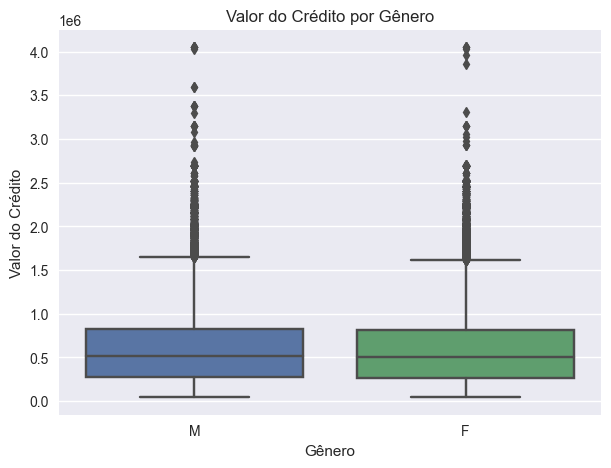

In [337]:
plt.figure(figsize=(7, 5))

sns.boxplot(
    data=df_eda,
    x="CODE_GENDER",
    y="AMT_CREDIT"
)

plt.title("Valor do Crédito por Gênero")
plt.xlabel("Gênero")
plt.ylabel("Valor do Crédito")

plt.show()

**Análise**

Apesar do genero feminino estar em mais quantidade, a taxa de inadimplência é mais concentrada nos homens. Foi analisado que emprestimos solicitados pelo sexo masculino é maior do que o feminio. O que nos leva a pensar na possibilidade do comprometimento da renda em relação ao valor do crédito solicitado e o salário anual do indivíduo.

In [338]:
df_eda['COMPROMETIMENTO_RENDA_PCT'] = (
    df_eda['AMT_ANNUITY'] / df_eda['AMT_INCOME_TOTAL']
) * 100

C:\Users\eduar\AppData\Local\Temp\ipykernel_1240\2156334768.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_eda['COMPROMETIMENTO_RENDA_PCT'] = (


### Os homens apresentam maior comprometimento da renda com o financiamento em comparação às mulheres, e isso está associado à maior taxa de inadimplência?

In [339]:
df_eda.groupby('CODE_GENDER')['COMPROMETIMENTO_RENDA_PCT'].agg(
    n='count',
    media='mean',
    mediana='median',
    std='std'
).round(2)

,n,media,mediana,std
CODE_GENDER,,,,
F,202440,18.90,16.96,9.90
M,105055,16.54,15.11,8.33


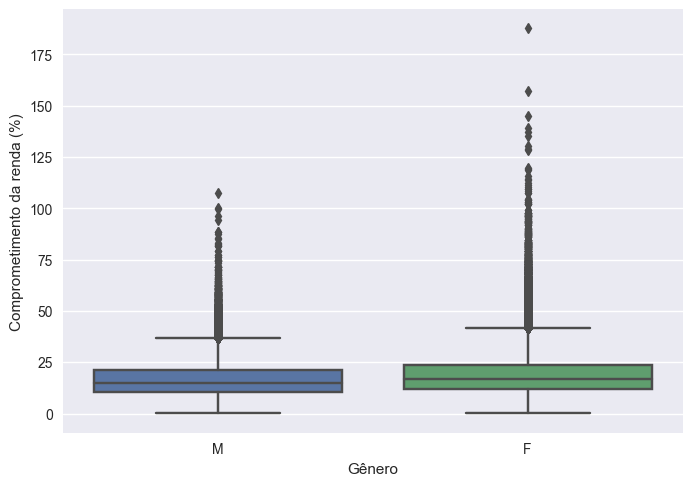

In [340]:
sns.boxplot(
    data=df_eda,
    x='CODE_GENDER',
    y='COMPROMETIMENTO_RENDA_PCT'
)
plt.ylabel('Comprometimento da renda (%)')
plt.xlabel('Gênero')
plt.show()

**Análise**

Mulheres possuem maior compromentimento de renda em relação aos homens,  mesmo os homens tendo uma taxa de inadimplência maior e solicitam valores de empréstimos mais altos.

In [341]:
df_eda

,SK_ID_CURR,TARGET,NAME_CONTRACT_TYPE,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,...,LANDAREA_missing,BASEMENTAREA_missing,NONLIVINGAREA_missing,ELEVATORS_missing,APARTMENTS_missing,ENTRANCES_missing,LIVINGAREA_missing,EXT_SOURCE_COMPLT_MEAN,EXT_SOURCE_COMPLT_SUM,COMPROMETIMENTO_RENDA_PCT
0,100002,1,Cash loans,M,N,Y,0,202500.0,406597.5,24700.5,...,0,0,0,0,0,0,0,0.161787,0.485361,12.197778
1,100003,0,Cash loans,F,N,N,0,270000.0,1293502.5,35698.5,...,0,0,0,0,0,0,0,0.466757,0.933513,13.221667
2,100004,0,Revolving loans,M,Y,Y,0,67500.0,135000.0,6750.0,...,1,1,1,1,1,1,1,0.642739,1.285479,10.000000
3,100006,0,Cash loans,F,N,Y,0,135000.0,312682.5,29686.5,...,1,1,1,1,1,1,1,0.650442,0.650442,21.990000
4,100007,0,Cash loans,M,N,Y,0,121500.0,513000.0,21865.5,...,1,1,1,1,1,1,1,0.322738,0.322738,17.996296
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
307506,456251,0,Cash loans,M,N,N,0,157500.0,254700.0,27558.0,...,0,0,0,0,0,0,0,0.413601,0.827203,17.497143
307507,456252,0,Cash loans,F,N,Y,0,72000.0,269550.0,12001.5,...,0,0,0,0,0,0,0,0.115992,0.115992,16.668750
307508,456253,0,Cash loans,F,N,Y,0,153000.0,677664.0,29979.0,...,1,0,0,0,0,0,0,0.499536,1.498607,19.594118
307509,456254,1,Cash loans,F,N,Y,0,171000.0,370107.0,20205.0,...,1,1,1,1,0,0,0,0.587593,1.175186,11.815789


### Análise de Outliers



In [342]:
variaveis = [
    'AMT_INCOME_TOTAL',
    'AMT_CREDIT',
    'AMT_ANNUITY',
    'COMPROMETIMENTO_RENDA_PCT'
]

X = df_eda[variaveis].copy()

In [343]:
X = X.fillna(X.median())

In [344]:
from sklearn.ensemble import IsolationForest

iso = IsolationForest(
    n_estimators=200,
    contamination='auto',   # ou 0.01, 0.02...
    random_state=42,
    n_jobs=-1
)

df_eda['OUTLIER_IF'] = iso.fit_predict(X)

C:\Users\eduar\AppData\Local\Temp\ipykernel_1240\537396136.py:10: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_eda['OUTLIER_IF'] = iso.fit_predict(X)


In [345]:
df_eda['OUTLIER_IF'].value_counts()

OUTLIER_IF
 1    259402
-1     48105
Name: count, dtype: int64

In [346]:
df_eda.loc[
    df_eda['OUTLIER_IF'] == -1,
    variaveis + ['TARGET']
].describe()

,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,COMPROMETIMENTO_RENDA_PCT,TARGET
count,4.810500e+04,4.810500e+04,48104.000000,48104.000000,48105.000000
mean,2.516913e+05,9.548885e+05,41549.649135,23.636789,0.061927
std,5.759883e+05,5.986757e+05,22576.813769,16.088132,0.241025
min,2.565000e+04,4.500000e+04,1615.500000,0.022388,0.000000
25%,1.125000e+05,4.725000e+05,25195.500000,9.880882,0.000000
50%,2.250000e+05,9.423000e+05,44442.000000,20.987500,0.000000
75%,3.600000e+05,1.374480e+06,55723.500000,35.961000,0.000000
max,1.170000e+08,4.050000e+06,258025.500000,187.596491,1.000000


In [347]:
outliers = df_eda[df_eda['OUTLIER_IF'] == -1]
normais = df_eda[df_eda['OUTLIER_IF'] == 1]

print("Taxa de inadimplência dos outliers:",
      outliers['TARGET'].mean())

print("Taxa de inadimplência dos normais:",
      normais['TARGET'].mean())

Taxa de inadimplência dos outliers: 0.06192703461178672
Taxa de inadimplência dos normais: 0.08421677550674243


In [348]:
variaveis = [
    'AMT_INCOME_TOTAL',
    'AMT_CREDIT',
    'AMT_ANNUITY',
    'COMPROMETIMENTO_RENDA_PCT'
]

df_eda.groupby('OUTLIER_IF')[variaveis].median().round(2)

,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,COMPROMETIMENTO_RENDA_PCT
OUTLIER_IF,,,,
-1,225000.0,942300.0,44442.0,20.99
1,135000.0,477000.0,23692.5,15.98


In [349]:
df_eda.groupby('OUTLIER_IF')[variaveis].mean().round(2)

,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,COMPROMETIMENTO_RENDA_PCT
OUTLIER_IF,,,,
-1,251691.30,954888.51,41549.65,23.64
1,153425.42,533035.89,24430.59,17.07


A aplicação do Isolation Forest identificou um conjunto de clientes com perfil financeiro atípico. Entretanto, esses clientes apresentaram taxa de inadimplência inferior à dos demais (6,19% contra 8,42%), indicando que a atipicidade das variáveis financeiras analisadas não está associada, por si só, a maior risco de inadimplência.

In [350]:
df_eda = df_eda.drop('OUTLIER_IF', axis = 1)

In [351]:
from pathlib import Path

ROOT = Path.cwd().parent
caminho = ROOT / "data" / "interim" / "df_train.parquet"
df_eda.to_parquet(caminho, index=False)

### Divisao treino, teste e validacao

Sera feito a separação treino, teste e validação estratificada, 80% treino, 20% validação e 20% teste

In [352]:
caminho_dados = r'C:\Users\eduar\OneDrive\Documentos\portifolio\credit-risk\data\raw\application_train.csv'
dados_new = pd.read_csv(caminho_dados)

In [353]:
from sklearn.model_selection import train_test_split

# 1. Separa treino+validação e teste
X_temp, X_test, y_temp, y_test = train_test_split(
    dados_new.drop(columns='TARGET'),
    dados_new['TARGET'],
    test_size=0.20,
    stratify=dados_new['TARGET'],
    random_state=42
)

# 2. Separa treino e validação
X_train, X_val, y_train, y_val = train_test_split(
    X_temp,
    y_temp,
    test_size=0.20,
    stratify=y_temp,
    random_state=42
)

# Resumo
print(f"X_train: {X_train.shape}")
print(f"X_val:   {X_val.shape}")
print(f"X_test:  {X_test.shape}")

print(f"\ny_train: {y_train.shape}")
print(f"y_val:   {y_val.shape}")
print(f"y_test:  {y_test.shape}")

print("\nTaxa de inadimplência")
print(f"Treino:    {y_train.mean():.4%}")
print(f"Validação: {y_val.mean():.4%}")
print(f"Teste:     {y_test.mean():.4%}")

X_train: (196806, 121)
X_val:   (49202, 121)
X_test:  (61503, 121)

y_train: (196806,)
y_val:   (49202,)
y_test:  (61503,)

Taxa de inadimplência
Treino:    8.0729%
Validação: 8.0728%
Teste:     8.0728%


In [354]:
def transformar_dados(df):
    df = df.copy()

    # Variáveis a remover
    cols_remover = [
        "COMMONAREA_MEDI", "COMMONAREA_MODE",
        "NONLIVINGAPARTMENTS_MEDI", "NONLIVINGAPARTMENTS_MODE",
        "LIVINGAPARTMENTS_MEDI", "LIVINGAPARTMENTS_MODE",
        "FLOORSMIN_AVG", "FLOORSMIN_MODE",
        "YEARS_BUILD_AVG", "YEARS_BUILD_MEDI",
        "LANDAREA_AVG", "LANDAREA_MODE",
        "BASEMENTAREA_MEDI", "BASEMENTAREA_MODE",
        "NONLIVINGAREA_MEDI", "NONLIVINGAREA_MODE",
        "ELEVATORS_MEDI", "ELEVATORS_MODE",
        "APARTMENTS_MEDI", "APARTMENTS_MODE",
        "ENTRANCES_MEDI", "ENTRANCES_MODE",
        "LIVINGAREA_MEDI", "LIVINGAREA_MODE", "CODE_GENDER", # removendo variavel de genero pois da vies no modelo
        "SK_ID_CURR",
        # Variaveis extremamente redundantes
        "FLAG_DOCUMENT_2", "FLAG_MOBIL", "FLAG_DOCUMENT_4", "FLAG_DOCUMENT_10", "FLAG_DOCUMENT_12"
    ]

    df.drop(columns=cols_remover, inplace=True)

    # Flags de missing
    grupos_missing = {
        "COMMONAREA_missing": "COMMONAREA_AVG",
        "NONLIVINGAPARTMENTS_missing": "NONLIVINGAPARTMENTS_AVG",
        "LIVINGAPARTMENTS_missing": "LIVINGAPARTMENTS_AVG",
        "FLOORSMIN_missing": "FLOORSMIN_MEDI",
        "YEARS_BUILD_missing": "YEARS_BUILD_MODE",
        "LANDAREA_missing": "LANDAREA_MEDI",
        "BASEMENTAREA_missing": "BASEMENTAREA_AVG",
        "NONLIVINGAREA_missing": "NONLIVINGAREA_AVG",
        "ELEVATORS_missing": "ELEVATORS_AVG",
        "APARTMENTS_missing": "APARTMENTS_AVG",
        "ENTRANCES_missing": "ENTRANCES_AVG",
        "LIVINGAREA_missing": "LIVINGAREA_AVG"
    }

    for nova_col, col_ref in grupos_missing.items():
        df[nova_col] = df[col_ref].isna().astype(int)

    # Features EXT_SOURCE
    ext_cols = ['EXT_SOURCE_1', 'EXT_SOURCE_2', 'EXT_SOURCE_3']

    df['EXT_SOURCE_COMPLT_MEAN'] = df[ext_cols].mean(axis=1)
    df['EXT_SOURCE_COMPLT_SUM'] = df[ext_cols].sum(axis=1)

    # Comprometimento da renda
    df['COMPROMETIMENTO_RENDA_PCT'] = (
        df['AMT_ANNUITY'] / df['AMT_INCOME_TOTAL']
    ) * 100

    return df

In [355]:
# Aplicando engenharia de atributos
X_train = transformar_dados(X_train)
X_val = transformar_dados(X_val)
X_test = transformar_dados(X_test)

In [356]:
print("========== SHAPES ==========")
print(f"X_train: {X_train.shape}")
print(f"X_val:   {X_val.shape}")
print(f"X_test:  {X_test.shape}")

print("\n========== Nº DE COLUNAS ==========")
print(f"X_train: {X_train.shape[1]}")
print(f"X_val:   {X_val.shape[1]}")
print(f"X_test:  {X_test.shape[1]}")

========== SHAPES ==========
X_train: (196806, 105)
X_val:   (49202, 105)
X_test:  (61503, 105)

========== Nº DE COLUNAS ==========
X_train: 105
X_val:   105
X_test:  105


In [357]:
from pathlib import Path

output_dir = Path(r"C:\Users\eduar\OneDrive\Documentos\portifolio\credit-risk\data\interim")
output_dir.mkdir(parents=True, exist_ok=True)

# Salvar features
X_train.to_parquet(output_dir / "X_train.parquet", index=False)
X_val.to_parquet(output_dir / "X_val.parquet", index=False)
X_test.to_parquet(output_dir / "X_test.parquet", index=False)

# Salvar targets
y_train.to_frame().to_parquet(output_dir / "y_train.parquet", index=False)
y_val.to_frame().to_parquet(output_dir / "y_val.parquet", index=False)
y_test.to_frame().to_parquet(output_dir / "y_test.parquet", index=False)